<a href="https://colab.research.google.com/github/Valdan-D/remorse/blob/Lorenzo/Lorenzo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROGETTO DATAMANAGEMENT**

---

**Colonne dei datasets**
- occurrence_no: ID univoco dell’occorrenza fossile./
- record_type: tipo di record, di solito occurrence.
- reid_no: ID di eventuale reidentificazione del fossile./
- flags: segnala condizioni particolari del record./
- collection_no: ID della collezione/località fossile./
- identified_name: nome tassonomico identificato originariamente./
- identified_rank: rango tassonomico del nome identificato.
- identified_no: ID del taxon identificato./
- difference: differenza tra nome identificato e nome accettato.
- accepted_name: nome tassonomico accettato dalla PBDB./
- accepted_attr: autore/attribuzione del nome accettato.
- accepted_rank: rango tassonomico del nome accettato.
- accepted_no: ID del taxon accettato./
- early_interval: intervallo geologico iniziale./
- late_interval: intervallo geologico finale, se presente./
- max_ma: età massima stimata in milioni di anni fa./
- min_ma: età minima stimata in milioni di anni fa./
- reference_no: ID della fonte bibliografica.
- lng: longitudine della località fossile./
- lat: latitudine della località fossile./
- cc: codice del paese./
- state: stato, provincia o regione./
- county: contea o area locale./
- latlng_basis: metodo usato per determinare le coordinate./
- latlng_precision: precisione delle coordinate geografiche./
- altitude_value: altitudine della località, se disponibile./
- altitude_unit: unità di misura dell’altitudine./
- geogscale: scala geografica della località./
- geogcomments: commenti sulla posizione geografica.
- cx_int_no: ID dell’intervallo geologico associato./
- formation: formazione geologica del ritrovamento./
- geological_group: gruppo geologico/stratigrafico./
- member: membro stratigrafico più specifico.
- phylum: phylum tassonomico./
- class: classe tassonomica./
- order: ordine tassonomico./
- family: famiglia tassonomica./
- genus: genere tassonomico./

<br>

---









## Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df_dino = pd.read_csv('dinos.csv')
df_plant = pd.read_csv('plants.csv')

## DINO



### Statistiche base del dataset

In [21]:
df_dino.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,at Dummer's Copse between Allington Lane and Q...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,"at Dummer's Copse, between Allington Lane and ...",37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,"Chaoyang area of Liaoning Province, NE China",2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx


In [22]:
df_dino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37790 entries, 0 to 37789
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     37790 non-null  int64  
 1   record_type       37790 non-null  object 
 2   reid_no           4154 non-null   float64
 3   flags             3417 non-null   object 
 4   collection_no     37790 non-null  int64  
 5   identified_name   37790 non-null  object 
 6   identified_rank   37790 non-null  object 
 7   identified_no     12703 non-null  float64
 8   difference        3889 non-null   object 
 9   accepted_name     37790 non-null  object 
 10  accepted_attr     37748 non-null  object 
 11  accepted_rank     37790 non-null  object 
 12  accepted_no       37790 non-null  int64  
 13  early_interval    37790 non-null  object 
 14  late_interval     8675 non-null   object 
 15  max_ma            37790 non-null  float64
 16  min_ma            37790 non-null  float6

In [23]:
df_dino.describe()

,occurrence_no,reid_no,collection_no,identified_no,accepted_no,max_ma,min_ma,reference_no,lng,lat,altitude_value,cx_int_no
count,3.779000e+04,4154.000000,37790.000000,12703.000000,37790.000000,37790.000000,37790.000000,37790.000000,37790.000000,37790.000000,8670.000000,37728.000000
mean,1.111161e+06,30509.549350,122537.062159,210102.997953,136205.014051,71.008821,64.523279,49143.774358,-19.988668,24.989404,991.356055,189.010549
std,4.505221e+05,8840.766784,73859.233773,136267.822972,132610.253551,65.819122,61.616788,26523.281573,92.791387,29.819606,1148.334106,294.044695
min,4.152400e+04,10063.000000,3256.000000,36610.000000,36616.000000,0.011700,0.000000,149.000000,-179.154999,-84.333336,-917.000000,1.000000
25%,6.322072e+05,22477.250000,53074.000000,91970.000000,38831.000000,0.129000,0.011700,24059.000000,-106.646927,18.330000,192.000000,37.000000
50%,1.273561e+06,32464.500000,109831.500000,143772.000000,64125.000000,72.200000,66.000000,55247.500000,-17.858500,37.404999,689.000000,112.000000
75%,1.468913e+06,38361.750000,194642.000000,368309.000000,186242.000000,121.400000,100.500000,70791.000000,35.373600,43.572224,1334.000000,119.000000
max,2.066136e+06,43269.000000,279154.000000,515615.000000,520798.000000,251.902000,248.100000,327912.000000,178.677002,89.039169,10421.000000,1203.000000


### Creazione dataframe dinosauri pulito e utilizzabile

In [24]:
colonne_utili_dino = [
    "occurrence_no",
    "collection_no",
    "accepted_name",
    "accepted_rank",
    "accepted_no",
    "identified_name",
    "early_interval",
    "late_interval",
    "max_ma",
    "min_ma",
    "lng",
    "lat",
    "cc",
    "state",
    "county",
    "latlng_basis",
    "latlng_precision",
    "formation",
    "geological_group",
    "member",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
    "reference_no"
]

df_dino_clean = df_dino[colonne_utili_dino].copy()

In [25]:
df_dino_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37790 entries, 0 to 37789
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     37790 non-null  int64  
 1   collection_no     37790 non-null  int64  
 2   accepted_name     37790 non-null  object 
 3   accepted_rank     37790 non-null  object 
 4   accepted_no       37790 non-null  int64  
 5   identified_name   37790 non-null  object 
 6   early_interval    37790 non-null  object 
 7   late_interval     8675 non-null   object 
 8   max_ma            37790 non-null  float64
 9   min_ma            37790 non-null  float64
 10  lng               37790 non-null  float64
 11  lat               37790 non-null  float64
 12  cc                37773 non-null  object 
 13  state             31470 non-null  object 
 14  county            18729 non-null  object 
 15  latlng_basis      36179 non-null  object 
 16  latlng_precision  37790 non-null  object

In [26]:
df_dino_clean.isna().sum()

,0
occurrence_no,0
collection_no,0
accepted_name,0
accepted_rank,0
accepted_no,0
identified_name,0
early_interval,0
late_interval,29115
max_ma,0
min_ma,0


In [27]:
df_dino_clean.duplicated().sum()

np.int64(0)

In [28]:
coordinate_non_valide = df_dino_clean[
    (df_dino_clean["lat"].notna() & ~df_dino_clean["lat"].between(-90, 90)) |
    (df_dino_clean["lng"].notna() & ~df_dino_clean["lng"].between(-180, 180))
]
coordinate_non_valide


,occurrence_no,collection_no,accepted_name,accepted_rank,accepted_no,identified_name,early_interval,late_interval,max_ma,min_ma,...,latlng_precision,formation,geological_group,member,phylum,class,order,family,genus,reference_no


## Grafici di esplorazione

### Dino

In [29]:
# 1. Colori e stile comune
giallo = "#F2C94C"
verde = "#2E7D32"

sns.set_theme(style="whitegrid")
sns.set_palette([giallo, verde])

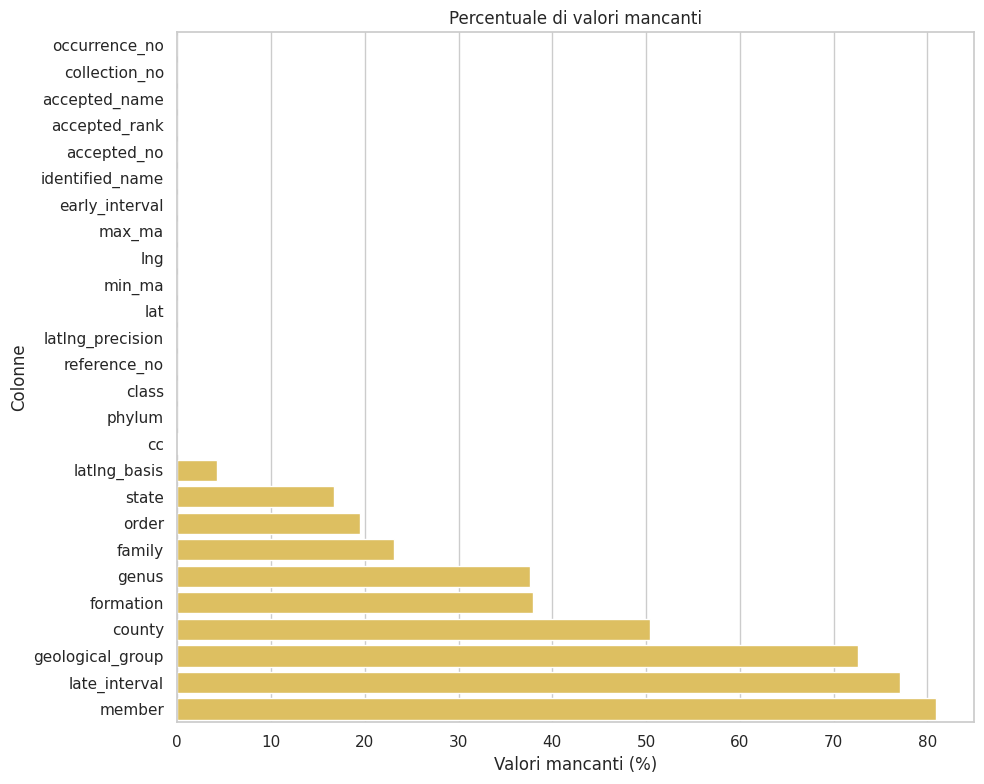

In [30]:
# 2. Percentuale di valori mancanti
valori_mancanti_dino = (df_dino_clean.isna().mean() * 100).sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(
    x=valori_mancanti_dino.values,
    y=valori_mancanti_dino.index,
    color=giallo
)
plt.title("Percentuale di valori mancanti")
plt.xlabel("Valori mancanti (%)")
plt.ylabel("Colonne")
plt.tight_layout()
plt.show()

In [31]:
# 3. Creazione delle colonne temporali
df_dino_clean["mid_ma"] = (
    df_dino_clean["max_ma"] + df_dino_clean["min_ma"]
) / 2

df_dino_clean["range_ma"] = (
    df_dino_clean["max_ma"] - df_dino_clean["min_ma"]
)

In [32]:
# 4. Selezione del Cretaceo
df_dino_cretaceo = df_dino_clean[
    df_dino_clean["mid_ma"].between(66, 145)
].copy()

In [33]:
# 5. Creazione degli intervalli da 10 milioni di anni
bins = [66, 75, 85, 95, 105, 115, 125, 135, 145]

etichette = [
    "66-75",
    "75-85",
    "85-95",
    "95-105",
    "105-115",
    "115-125",
    "125-135",
    "135-145"
]

ordine_periodi = etichette[::-1]

df_dino_cretaceo["periodo_10ma"] = pd.cut(
    df_dino_cretaceo["mid_ma"],
    bins=bins,
    labels=etichette,
    include_lowest=True
)

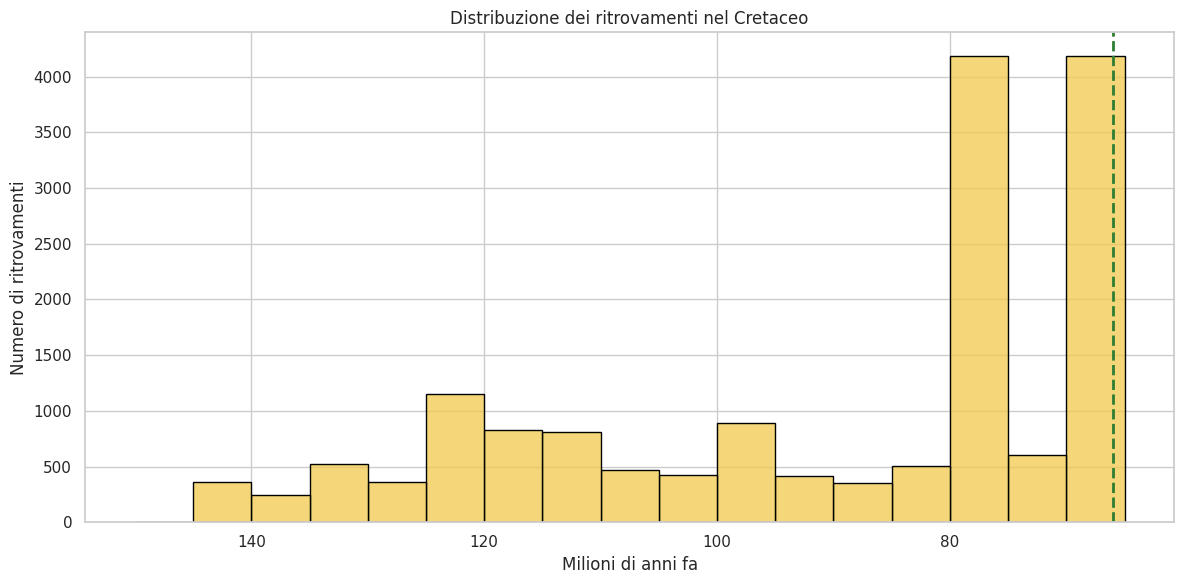

In [34]:
# 6. Distribuzione dei ritrovamenti nel tempo
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_dino_cretaceo,
    x="mid_ma",
    bins=np.arange(65, 151, 5),
    color=giallo,
    edgecolor="black"
)

plt.axvline(
    66,
    color=verde,
    linestyle="--",
    linewidth=2
)

plt.gca().invert_xaxis()
plt.title("Distribuzione dei ritrovamenti nel Cretaceo")
plt.xlabel("Milioni di anni fa")
plt.ylabel("Numero di ritrovamenti")
plt.tight_layout()
plt.show()

In [35]:
# 7. Tabella della biodiversità per periodo
biodiversita_dino = (
    df_dino_cretaceo
    .groupby("periodo_10ma", observed=True)
    .agg(
        generi=("genus", "nunique"),
        famiglie=("family", "nunique"),
        collezioni=("collection_no", "nunique"),
        ritrovamenti=("occurrence_no", "count")
    )
    .reindex(ordine_periodi)
)

specie_dino = (
    df_dino_cretaceo[
        df_dino_cretaceo["accepted_rank"] == "species"
    ]
    .groupby("periodo_10ma", observed=True)["accepted_name"]
    .nunique()
    .reindex(ordine_periodi)
)

biodiversita_dino["specie"] = specie_dino

biodiversita_dino

,generi,famiglie,collezioni,ritrovamenti,specie
periodo_10ma,,,,,
135-145,74,40,305,610,53
125-135,102,45,459,885,84
115-125,338,75,965,1974,332
105-115,147,59,694,1272,138
95-105,176,53,707,1317,173
85-95,126,41,354,775,126
75-85,388,75,2323,4693,425
66-75,359,76,2245,4793,400


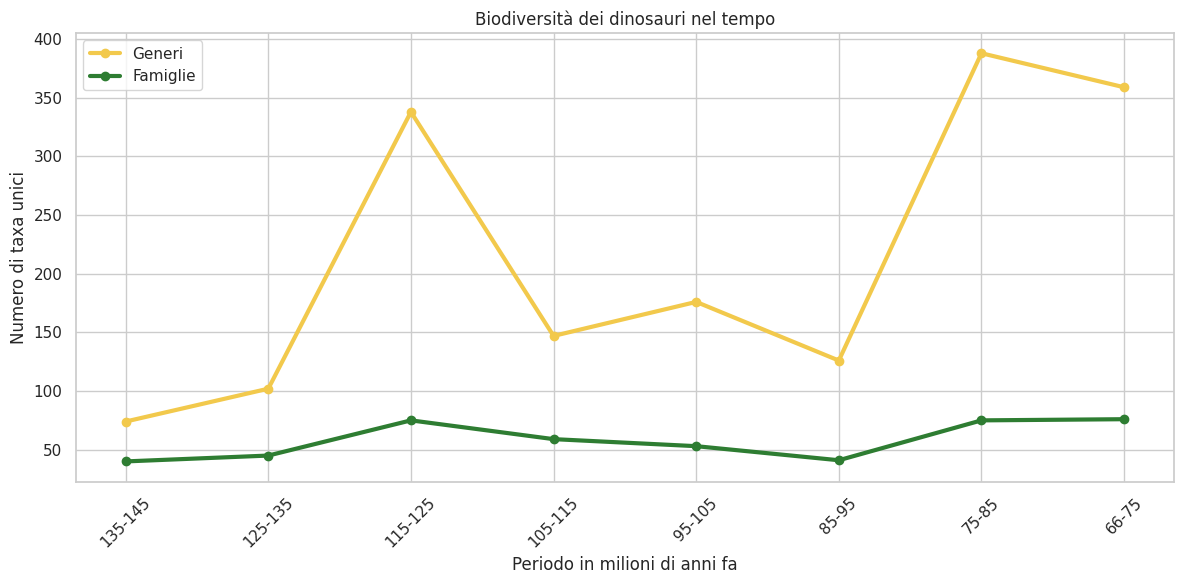

In [36]:
# 8. Generi e famiglie nel tempo
plt.figure(figsize=(12, 6))

plt.plot(
    biodiversita_dino.index,
    biodiversita_dino["generi"],
    marker="o",
    color=giallo,
    linewidth=3,
    label="Generi"
)

plt.plot(
    biodiversita_dino.index,
    biodiversita_dino["famiglie"],
    marker="o",
    color=verde,
    linewidth=3,
    label="Famiglie"
)

plt.title("Biodiversità dei dinosauri nel tempo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Numero di taxa unici")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

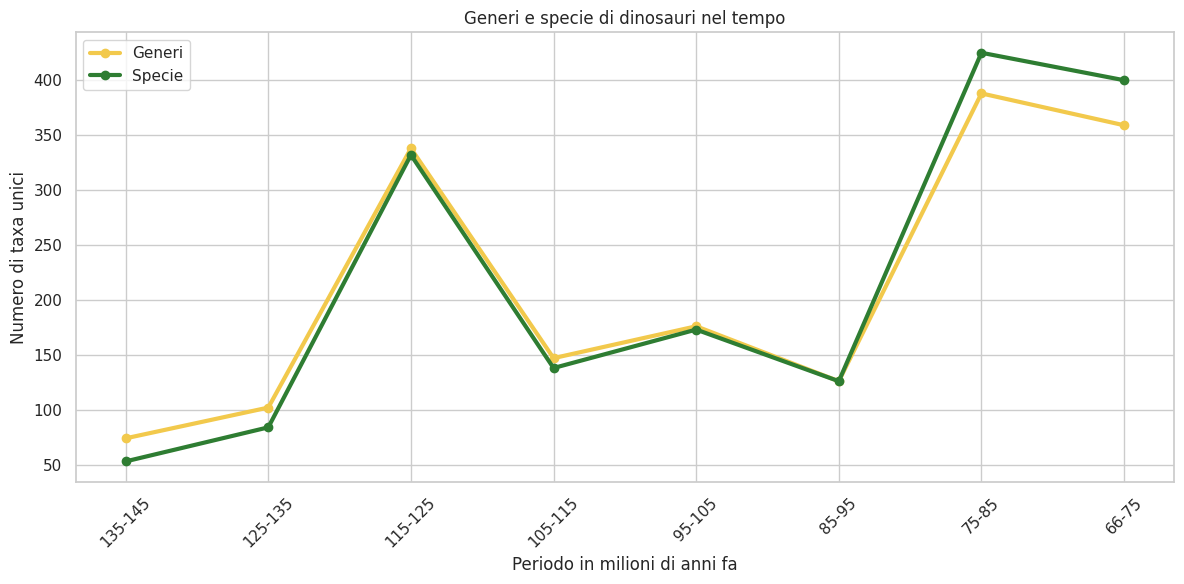

In [37]:
# 9. Generi e specie nel tempo
plt.figure(figsize=(12, 6))

plt.plot(
    biodiversita_dino.index,
    biodiversita_dino["generi"],
    marker="o",
    color=giallo,
    linewidth=3,
    label="Generi"
)

plt.plot(
    biodiversita_dino.index,
    biodiversita_dino["specie"],
    marker="o",
    color=verde,
    linewidth=3,
    label="Specie"
)

plt.title("Generi e specie di dinosauri nel tempo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Numero di taxa unici")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

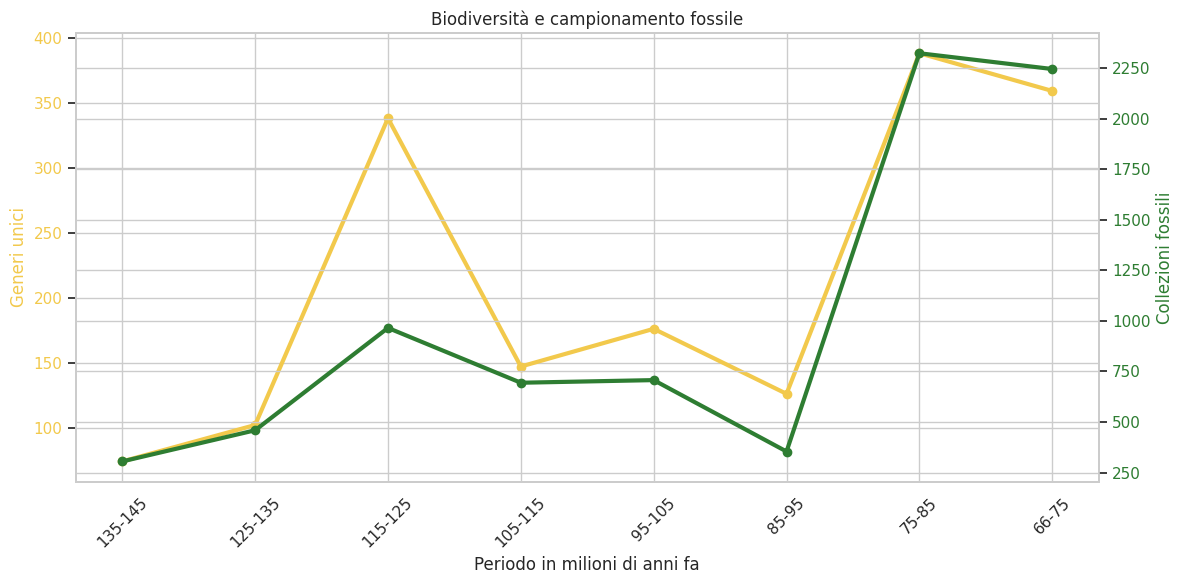

In [38]:
# 10. Biodiversità e quantità di collezioni
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    biodiversita_dino.index,
    biodiversita_dino["generi"],
    marker="o",
    color=giallo,
    linewidth=3
)

ax1.set_xlabel("Periodo in milioni di anni fa")
ax1.set_ylabel("Generi unici", color=giallo)
ax1.tick_params(axis="y", labelcolor=giallo)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    biodiversita_dino.index,
    biodiversita_dino["collezioni"],
    marker="o",
    color=verde,
    linewidth=3
)

ax2.set_ylabel("Collezioni fossili", color=verde)
ax2.tick_params(axis="y", labelcolor=verde)

plt.title("Biodiversità e campionamento fossile")
fig.tight_layout()
plt.show()

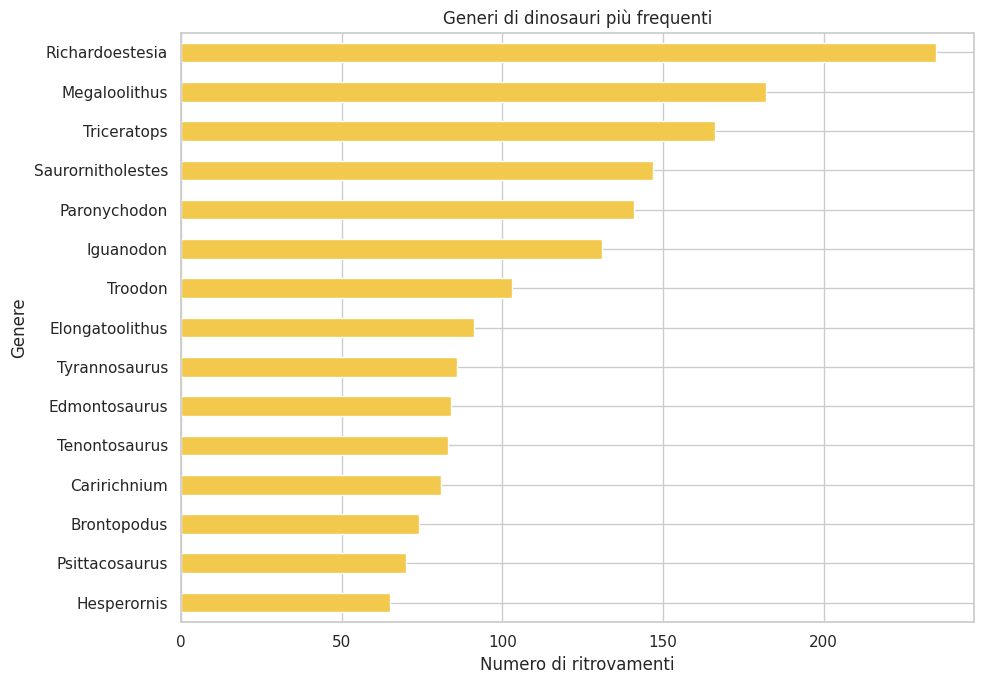

In [39]:
# 11. Generi più frequenti
generi_top = (
    df_dino_cretaceo["genus"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
generi_top.plot(kind="barh", color=giallo)
plt.title("Generi di dinosauri più frequenti")
plt.xlabel("Numero di ritrovamenti")
plt.ylabel("Genere")
plt.tight_layout()
plt.show()

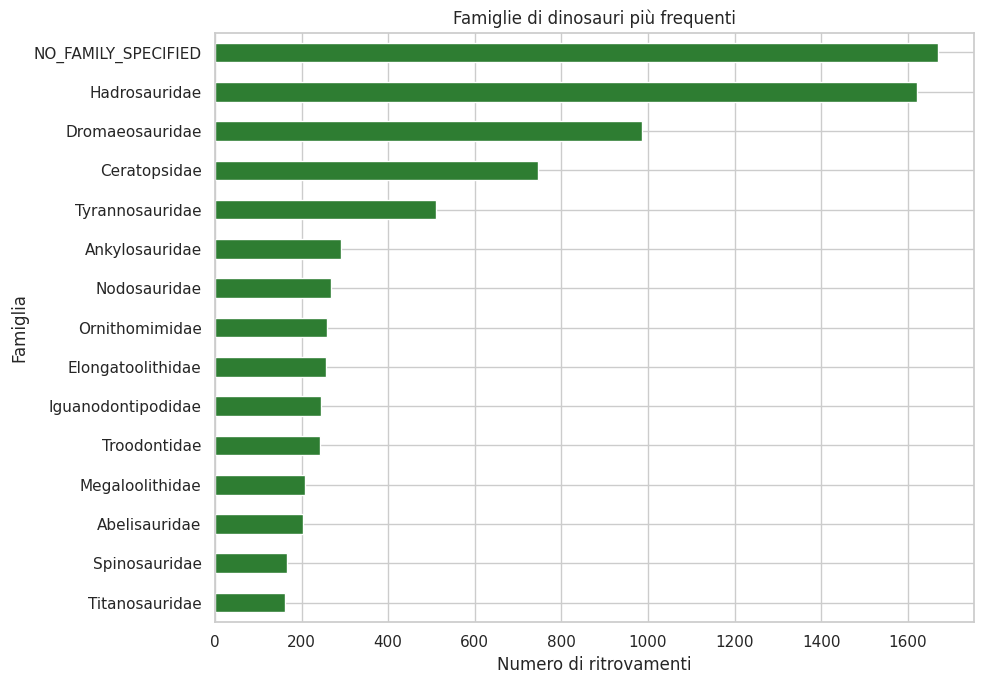

In [40]:
# 12. Famiglie più frequenti
famiglie_top = (
    df_dino_cretaceo["family"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
famiglie_top.plot(kind="barh", color=verde)
plt.title("Famiglie di dinosauri più frequenti")
plt.xlabel("Numero di ritrovamenti")
plt.ylabel("Famiglia")
plt.tight_layout()
plt.show()

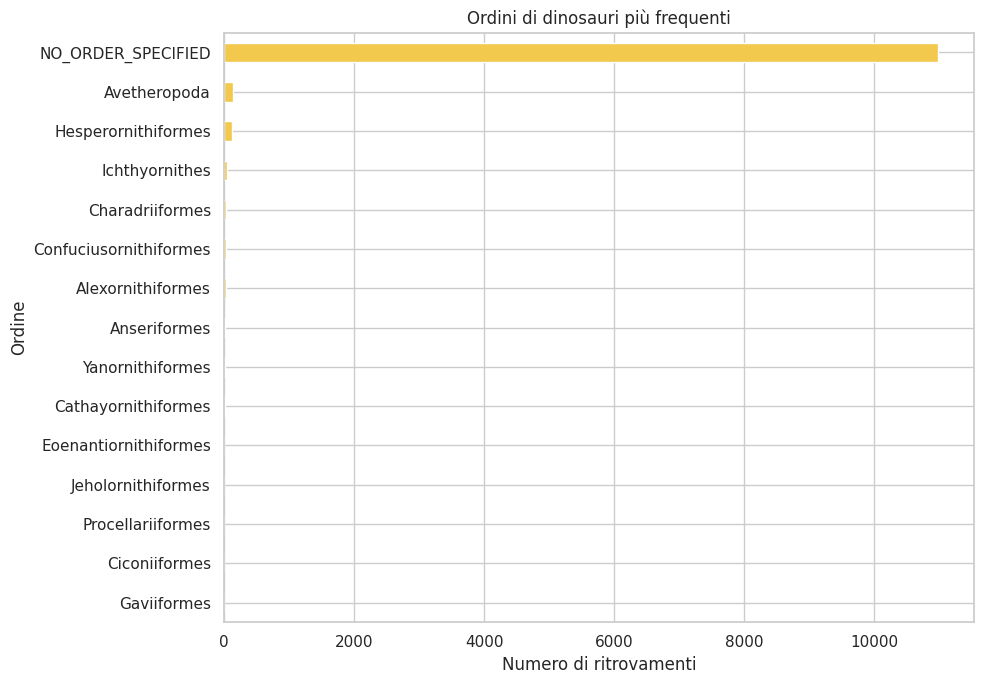

In [41]:
# 13. Ordini più frequenti
ordini_top = (
    df_dino_cretaceo["order"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
ordini_top.plot(kind="barh", color=giallo)
plt.title("Ordini di dinosauri più frequenti")
plt.xlabel("Numero di ritrovamenti")
plt.ylabel("Ordine")
plt.tight_layout()
plt.show()

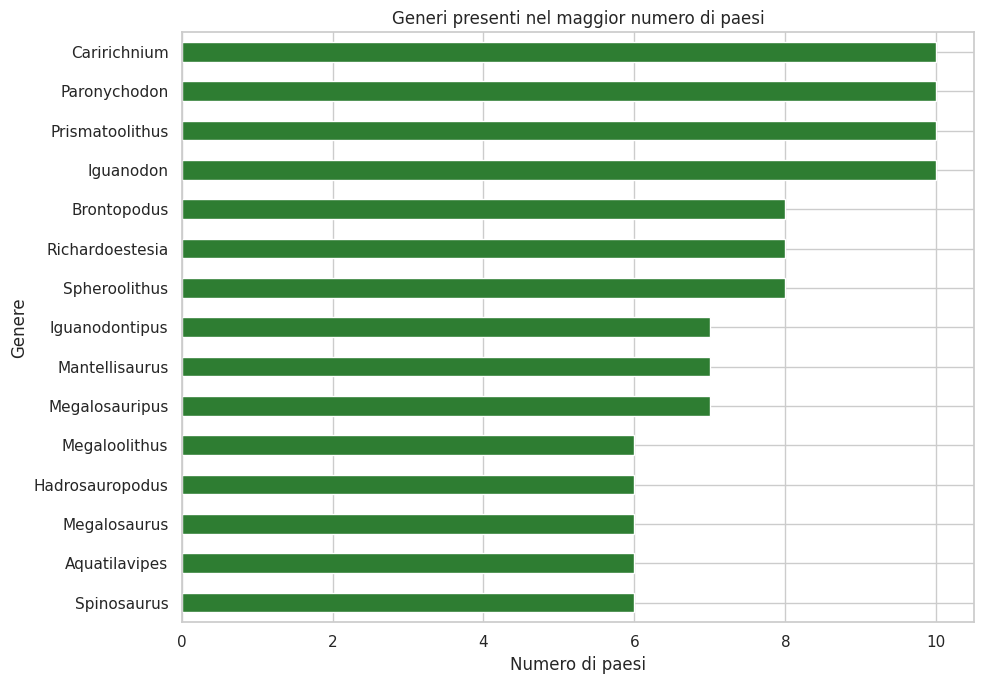

In [42]:
# 14. Generi presenti nel maggior numero di paesi
diffusione_generi = (
    df_dino_cretaceo
    .groupby("genus")["cc"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
diffusione_generi.plot(kind="barh", color=verde)
plt.title("Generi presenti nel maggior numero di paesi")
plt.xlabel("Numero di paesi")
plt.ylabel("Genere")
plt.tight_layout()
plt.show()

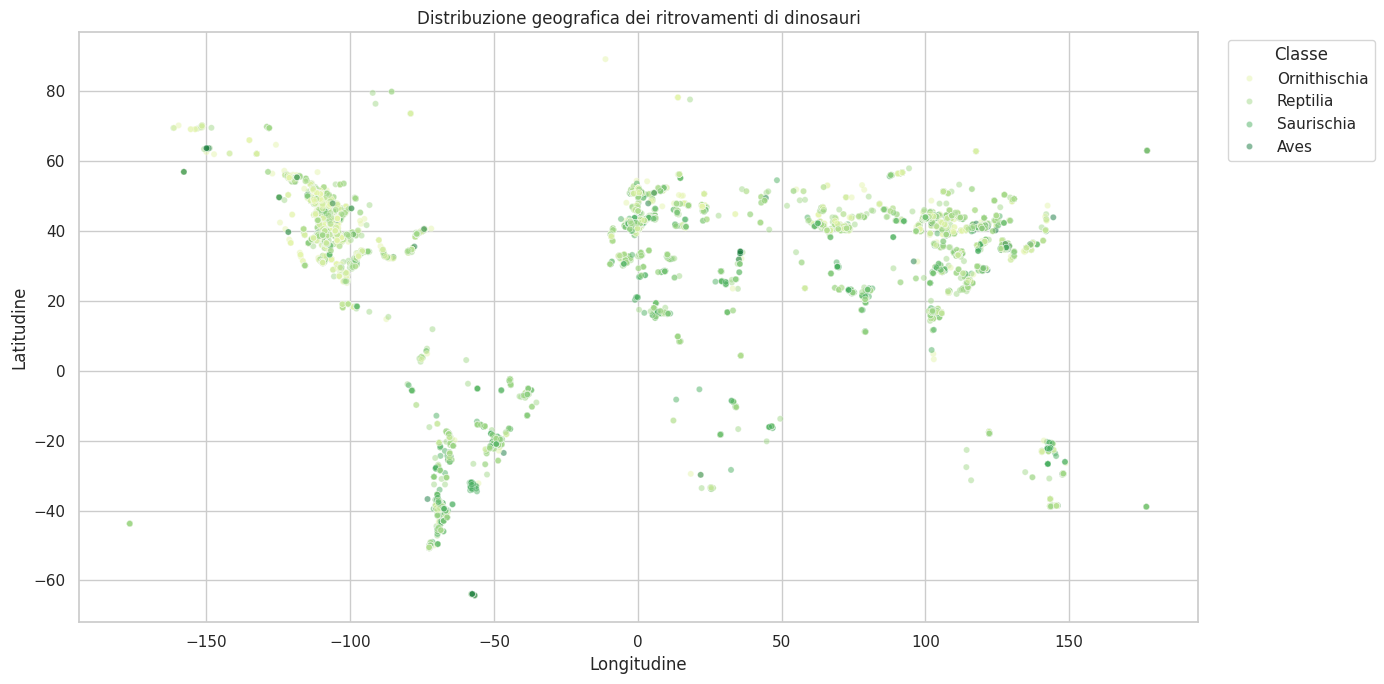

In [43]:
# 15. Distribuzione geografica dei ritrovamenti
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df_dino_cretaceo,
    x="lng",
    y="lat",
    hue="class",
    palette="YlGn",
    s=20,
    alpha=0.5
)

plt.title("Distribuzione geografica dei ritrovamenti di dinosauri")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.legend(title="Classe", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

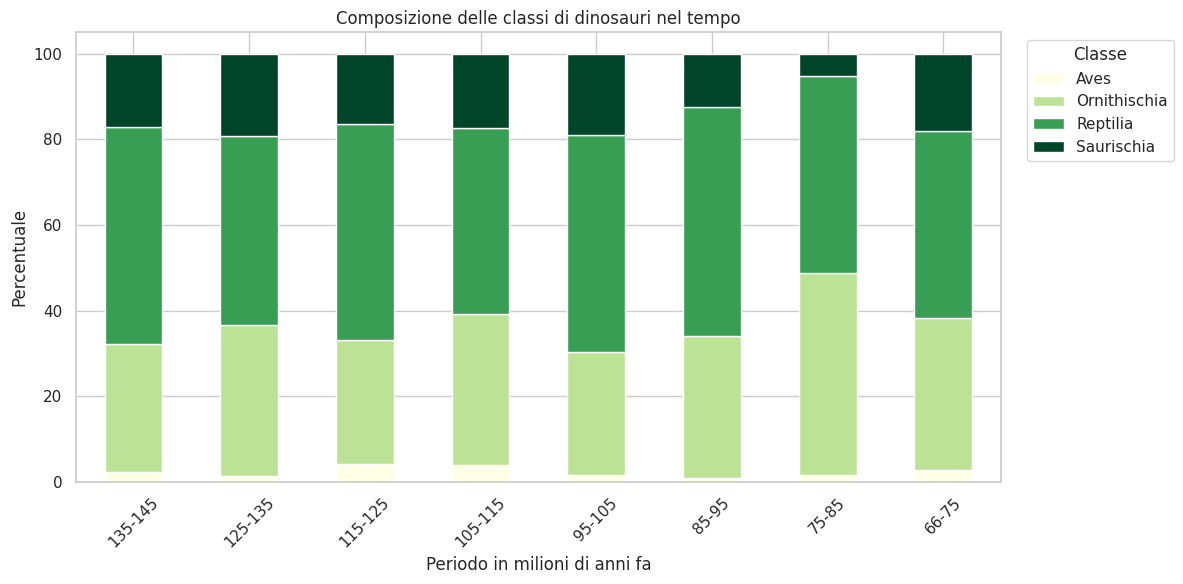

In [44]:
# 16. Composizione delle classi nel tempo
tabella_classi_dino = (
    pd.crosstab(
        df_dino_cretaceo["periodo_10ma"],
        df_dino_cretaceo["class"],
        normalize="index"
    )
    .mul(100)
    .reindex(ordine_periodi)
)

tabella_classi_dino.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="YlGn"
)

plt.title("Composizione delle classi di dinosauri nel tempo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Percentuale")
plt.xticks(rotation=45)
plt.legend(title="Classe", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

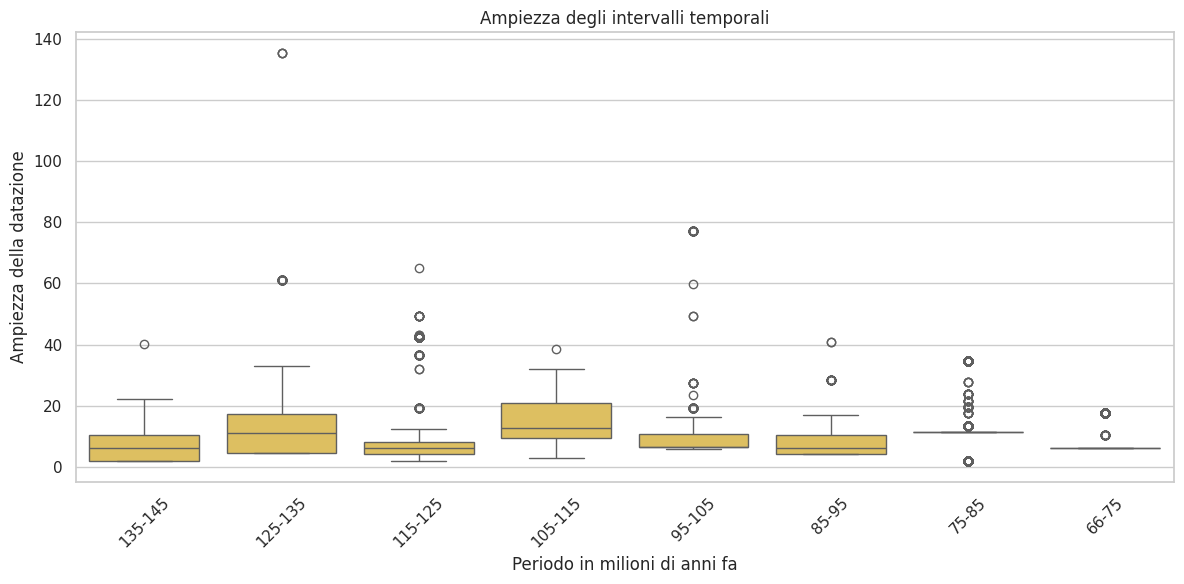

In [45]:
# 17. Incertezza della datazione fossile
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_dino_cretaceo,
    x="periodo_10ma",
    y="range_ma",
    order=ordine_periodi,
    color=giallo
)

plt.title("Ampiezza degli intervalli temporali")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Ampiezza della datazione")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plants

In [46]:
# 18 - Creazione del dataframe pulito delle piante

colonne_utili_plant = colonne_utili_dino.copy()

df_plant_clean = df_plant[colonne_utili_plant].copy()

In [47]:
# 19 - Controllo delle coordinate non valide delle piante

coordinate_non_valide_plant = df_plant_clean[
    (
        df_plant_clean["lat"].notna()
        & ~df_plant_clean["lat"].between(-90, 90)
    )
    |
    (
        df_plant_clean["lng"].notna()
        & ~df_plant_clean["lng"].between(-180, 180)
    )
]

coordinate_non_valide_plant

,occurrence_no,collection_no,accepted_name,accepted_rank,accepted_no,identified_name,early_interval,late_interval,max_ma,min_ma,...,latlng_precision,formation,geological_group,member,phylum,class,order,family,genus,reference_no


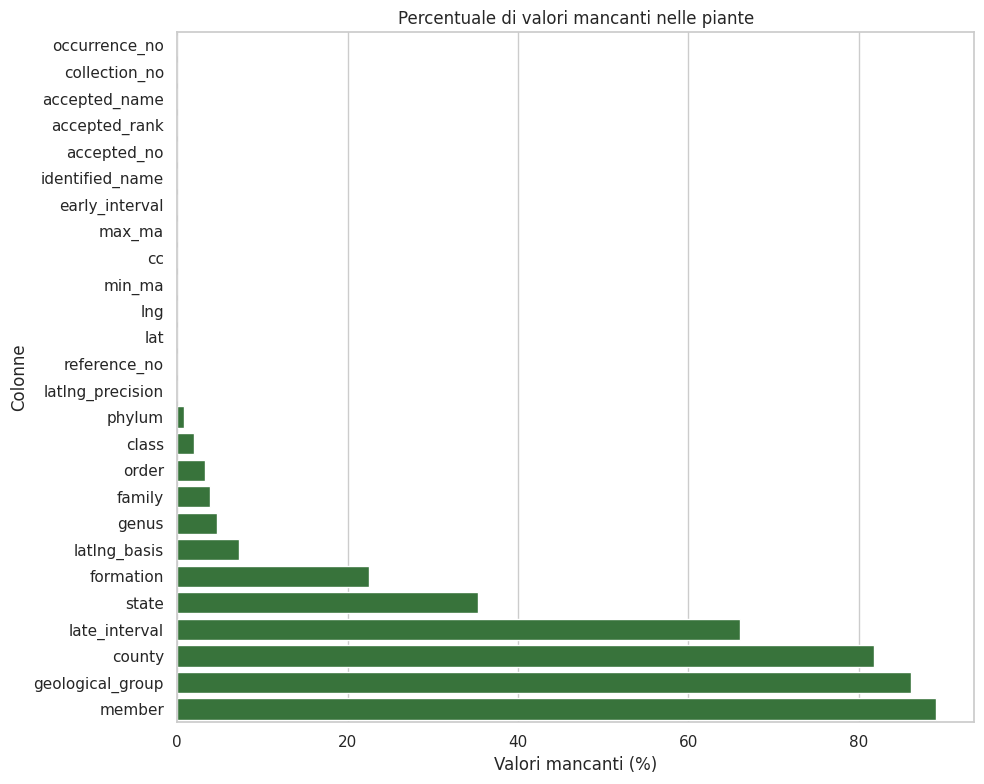

In [48]:
# 20 - Percentuale di valori mancanti nelle piante

valori_mancanti_plant = (
    df_plant_clean.isna().mean() * 100
).sort_values()

plt.figure(figsize=(10, 8))

sns.barplot(
    x=valori_mancanti_plant.values,
    y=valori_mancanti_plant.index,
    color=verde
)

plt.title("Percentuale di valori mancanti nelle piante")
plt.xlabel("Valori mancanti (%)")
plt.ylabel("Colonne")
plt.tight_layout()
plt.show()

In [49]:
# 21 - Creazione delle colonne temporali delle piante

df_plant_clean["mid_ma"] = (
    df_plant_clean["max_ma"] + df_plant_clean["min_ma"]
) / 2

df_plant_clean["range_ma"] = (
    df_plant_clean["max_ma"] - df_plant_clean["min_ma"]
)

df_plant_cretaceo = df_plant_clean[
    df_plant_clean["mid_ma"].between(66, 145)
].copy()

df_plant_cretaceo["periodo_10ma"] = pd.cut(
    df_plant_cretaceo["mid_ma"],
    bins=bins,
    labels=etichette,
    include_lowest=True
)

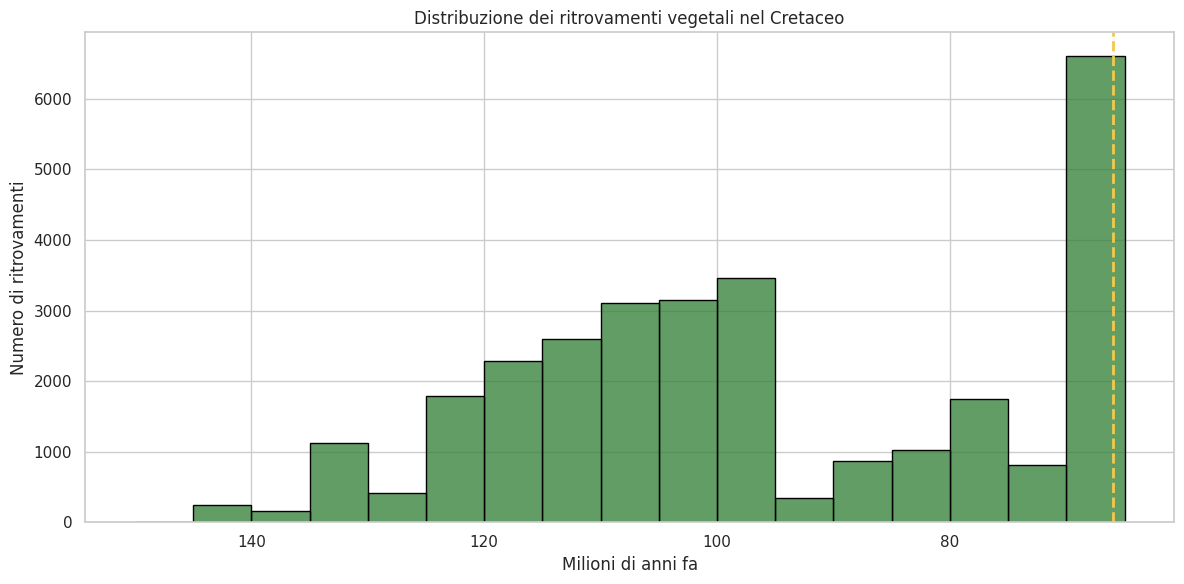

In [50]:
# 22 - Distribuzione dei ritrovamenti vegetali nel tempo

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_plant_cretaceo,
    x="mid_ma",
    bins=np.arange(65, 151, 5),
    color=verde,
    edgecolor="black"
)

plt.axvline(
    66,
    color=giallo,
    linestyle="--",
    linewidth=2
)

plt.gca().invert_xaxis()
plt.title("Distribuzione dei ritrovamenti vegetali nel Cretaceo")
plt.xlabel("Milioni di anni fa")
plt.ylabel("Numero di ritrovamenti")
plt.tight_layout()
plt.show()

In [51]:
# 23 - Tabella della biodiversità vegetale per periodo

biodiversita_plant = (
    df_plant_cretaceo
    .groupby("periodo_10ma", observed=True)
    .agg(
        generi=("genus", "nunique"),
        famiglie=("family", "nunique"),
        collezioni=("collection_no", "nunique"),
        ritrovamenti=("occurrence_no", "count")
    )
    .reindex(ordine_periodi)
)

specie_plant = (
    df_plant_cretaceo[
        df_plant_cretaceo["accepted_rank"] == "species"
    ]
    .groupby("periodo_10ma", observed=True)["accepted_name"]
    .nunique()
    .reindex(ordine_periodi)
)

biodiversita_plant["specie"] = specie_plant

biodiversita_plant

,generi,famiglie,collezioni,ritrovamenti,specie
periodo_10ma,,,,,
135-145,124,40,100,404,31
125-135,315,54,218,1541,308
115-125,512,102,568,4076,640
105-115,395,86,518,5702,509
95-105,476,100,967,6599,519
85-95,177,54,161,1209,160
75-85,520,149,522,2773,499
66-75,604,154,746,7425,641


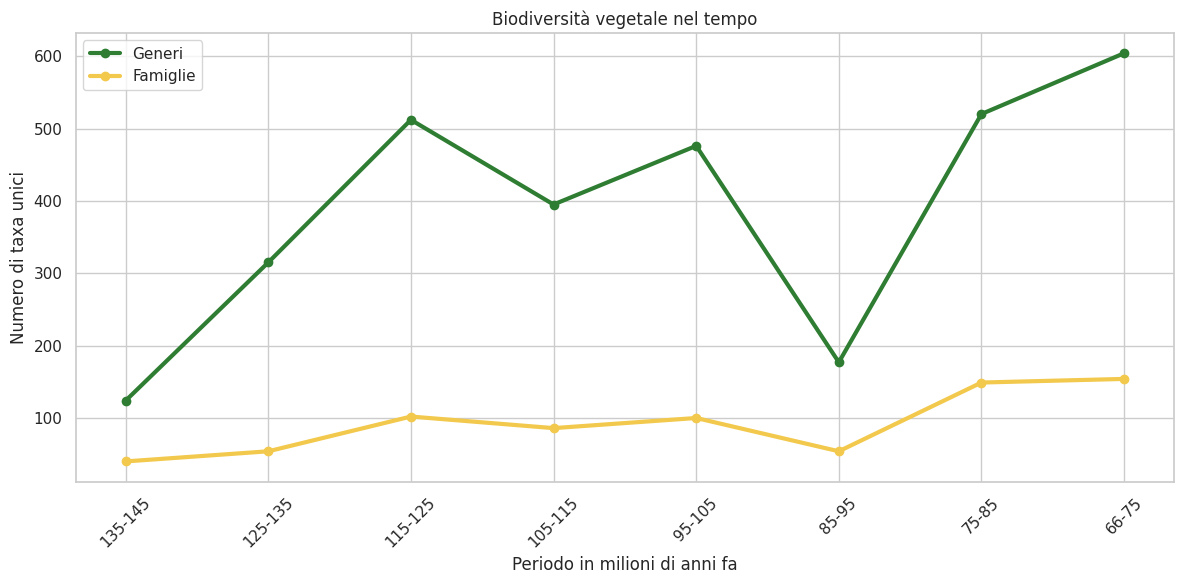

In [52]:
# 24 - Generi e famiglie vegetali nel tempo

plt.figure(figsize=(12, 6))

plt.plot(
    biodiversita_plant.index,
    biodiversita_plant["generi"],
    marker="o",
    color=verde,
    linewidth=3,
    label="Generi"
)

plt.plot(
    biodiversita_plant.index,
    biodiversita_plant["famiglie"],
    marker="o",
    color=giallo,
    linewidth=3,
    label="Famiglie"
)

plt.title("Biodiversità vegetale nel tempo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Numero di taxa unici")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

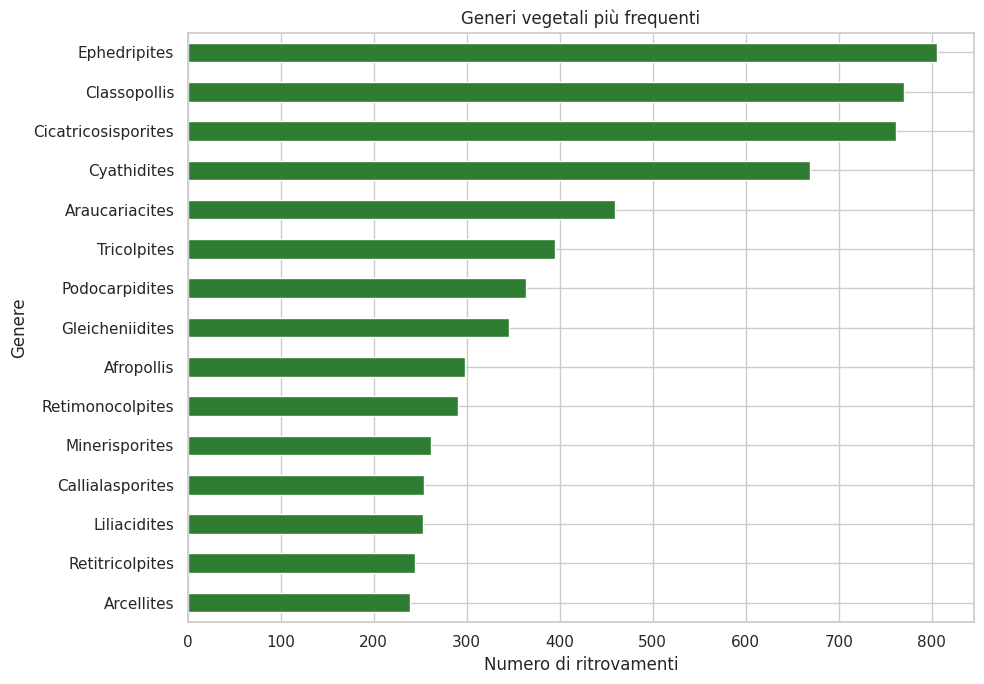

In [53]:
# 25 - Generi vegetali più frequenti

generi_plant_top = (
    df_plant_cretaceo["genus"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

generi_plant_top.plot(
    kind="barh",
    color=verde
)

plt.title("Generi vegetali più frequenti")
plt.xlabel("Numero di ritrovamenti")
plt.ylabel("Genere")
plt.tight_layout()
plt.show()

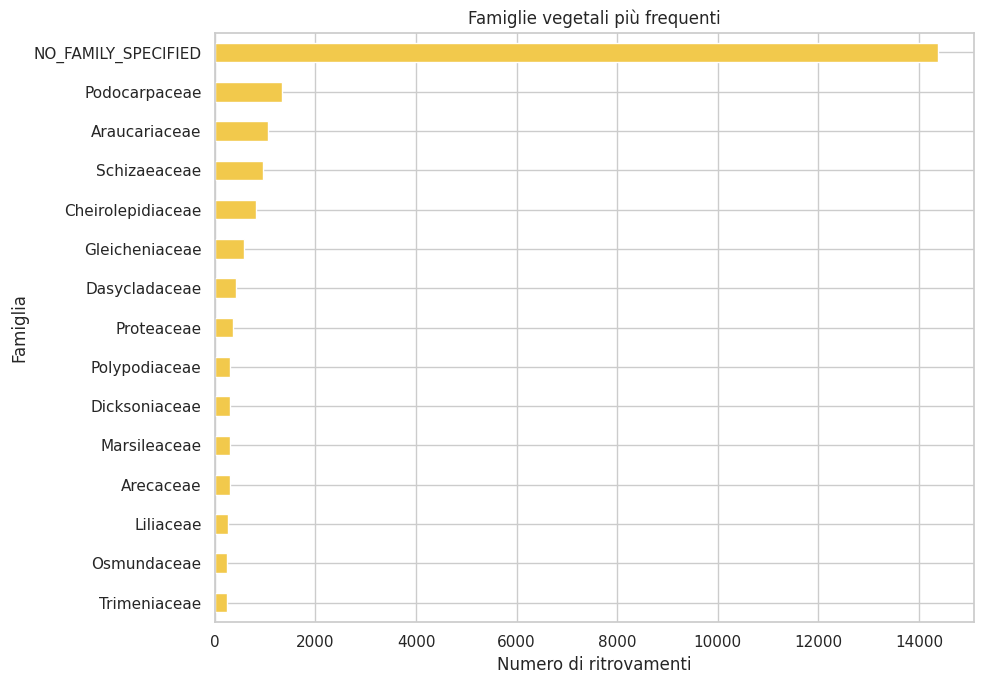

In [54]:
# 26 - Famiglie vegetali più frequenti

famiglie_plant_top = (
    df_plant_cretaceo["family"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

famiglie_plant_top.plot(
    kind="barh",
    color=giallo
)

plt.title("Famiglie vegetali più frequenti")
plt.xlabel("Numero di ritrovamenti")
plt.ylabel("Famiglia")
plt.tight_layout()
plt.show()

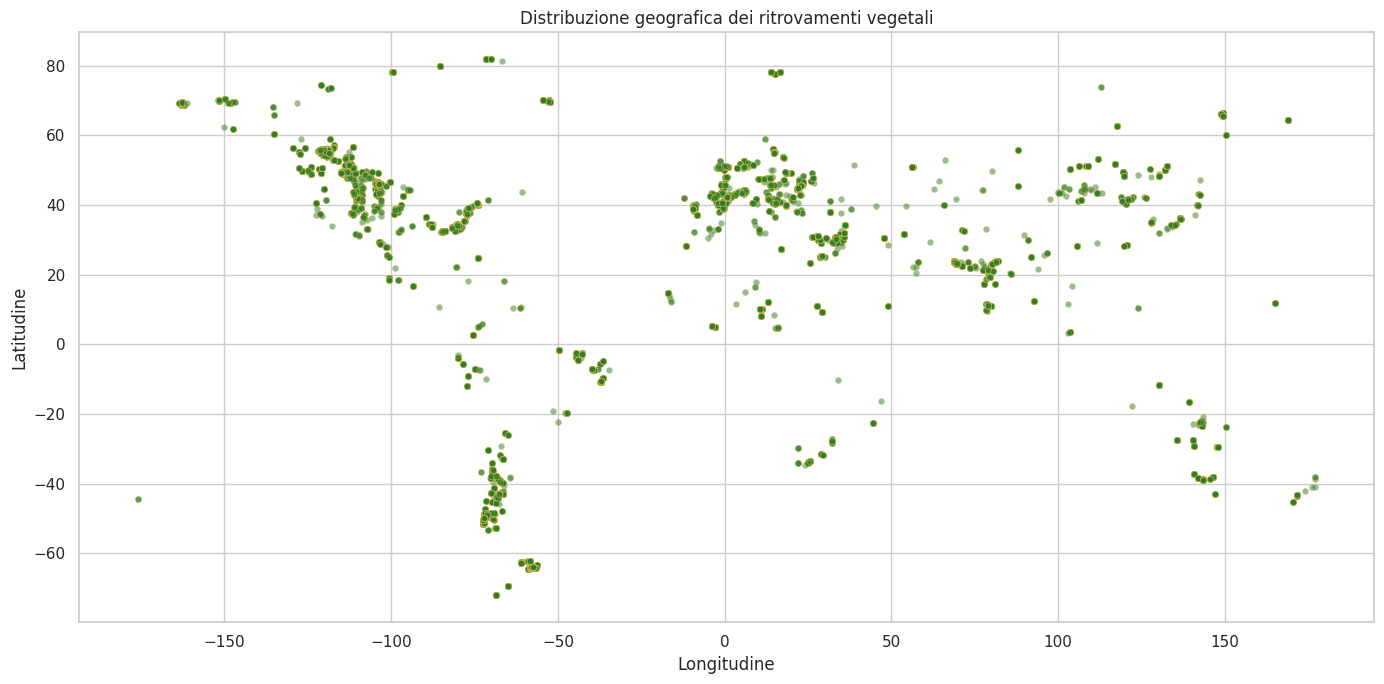

In [55]:
# 27 - Distribuzione geografica dei ritrovamenti vegetali

plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df_plant_cretaceo,
    x="lng",
    y="lat",
    color=verde,
    edgecolor=giallo,
    s=20,
    alpha=0.5
)

plt.title("Distribuzione geografica dei ritrovamenti vegetali")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.tight_layout()
plt.show()

In [56]:
# 28 - Raggruppamento delle classi vegetali meno frequenti

classi_top_plant = (
    df_plant_cretaceo["class"]
    .value_counts()
    .head(7)
    .index
)

df_plant_cretaceo["class_group"] = (
    df_plant_cretaceo["class"]
    .where(
        df_plant_cretaceo["class"].isin(classi_top_plant),
        "Altro"
    )
)

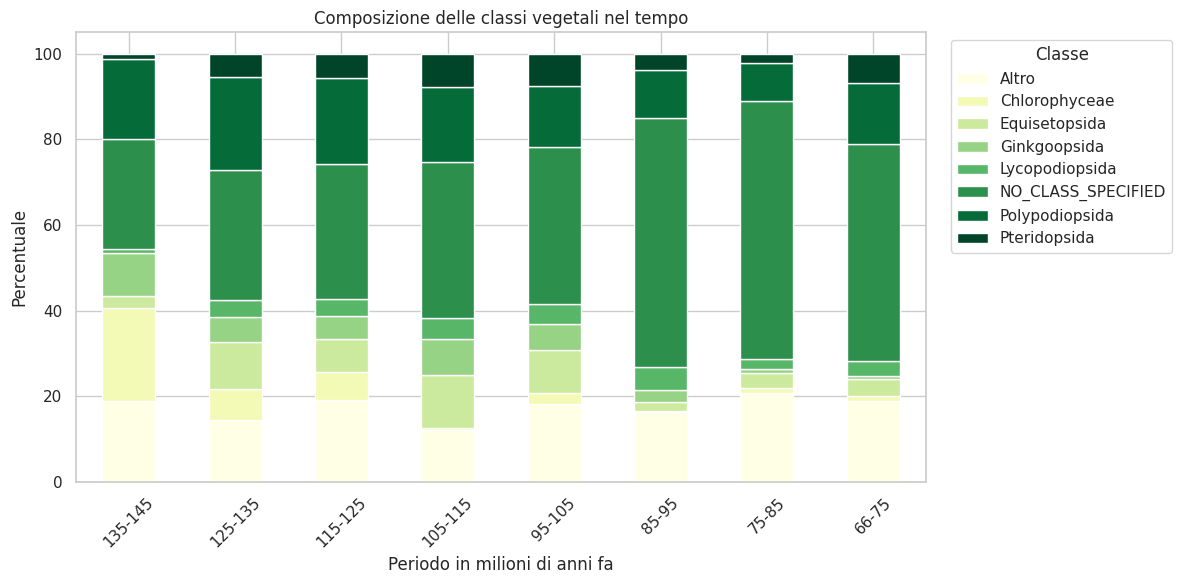

In [57]:
# 29 - Composizione delle classi vegetali nel tempo

tabella_classi_plant = (
    pd.crosstab(
        df_plant_cretaceo["periodo_10ma"],
        df_plant_cretaceo["class_group"],
        normalize="index"
    )
    .mul(100)
    .reindex(ordine_periodi)
)

tabella_classi_plant.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="YlGn"
)

plt.title("Composizione delle classi vegetali nel tempo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Percentuale")
plt.xticks(rotation=45)
plt.legend(title="Classe", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

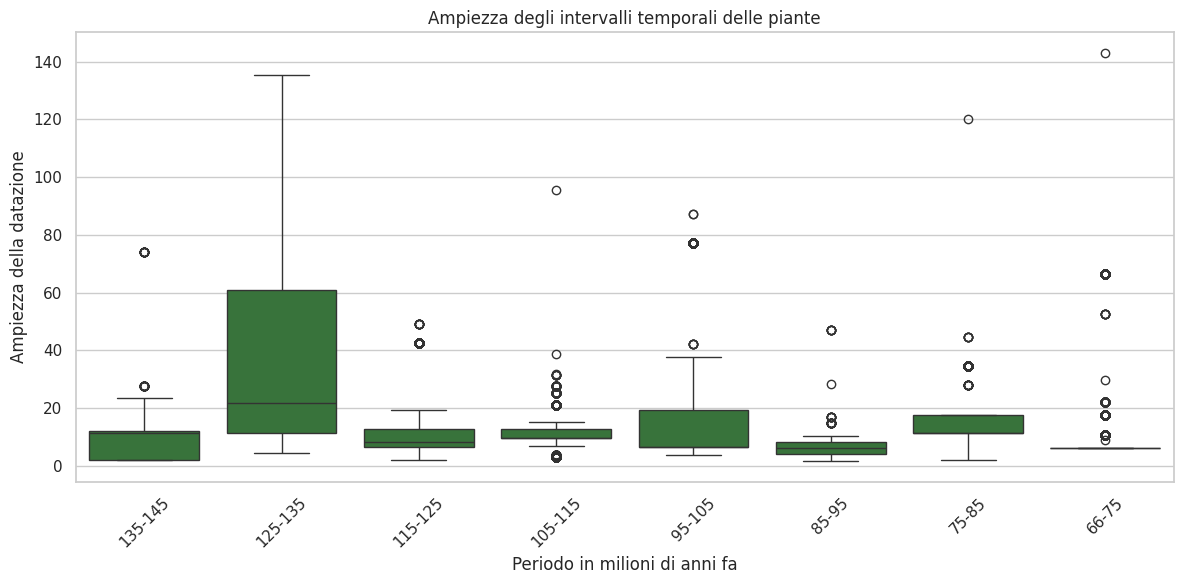

In [58]:
# 30 - Ampiezza degli intervalli temporali delle piante

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plant_cretaceo,
    x="periodo_10ma",
    y="range_ma",
    order=ordine_periodi,
    color=verde
)

plt.title("Ampiezza degli intervalli temporali delle piante")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Ampiezza della datazione")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
# 31 - Tabella di confronto della biodiversità

confronto_biodiversita = pd.DataFrame({
    "Generi dinosauri": biodiversita_dino["generi"],
    "Generi piante": biodiversita_plant["generi"]
}).reindex(ordine_periodi)

confronto_biodiversita

,Generi dinosauri,Generi piante
periodo_10ma,,
135-145,74,124
125-135,102,315
115-125,338,512
105-115,147,395
95-105,176,476
85-95,126,177
75-85,388,520
66-75,359,604


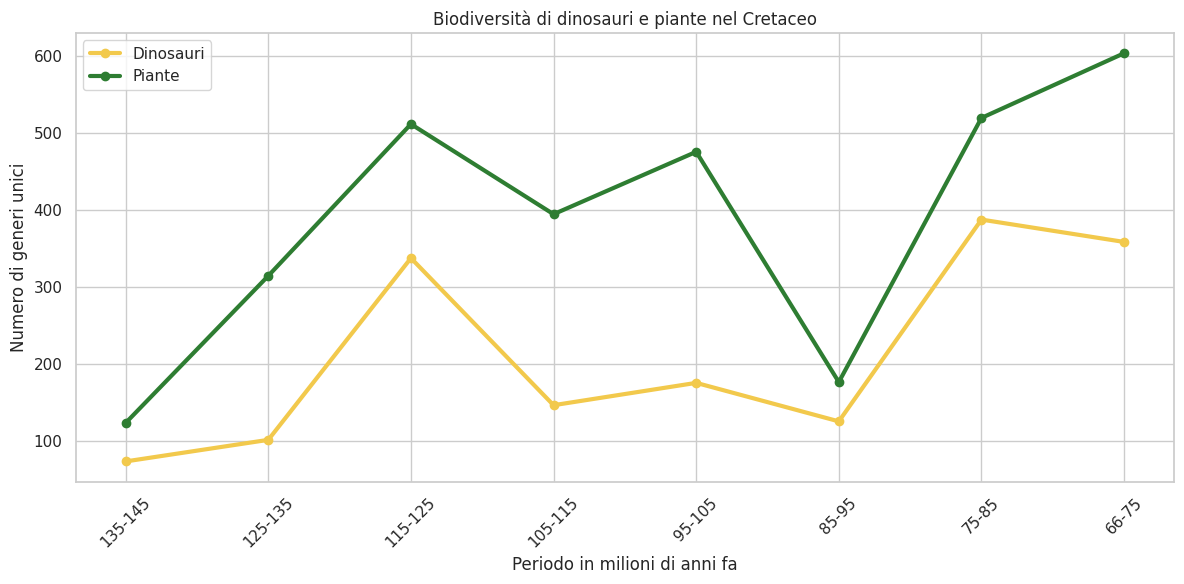

In [60]:
# 32 - Confronto della biodiversità di dinosauri e piante nel tempo

plt.figure(figsize=(12, 6))

plt.plot(
    confronto_biodiversita.index,
    confronto_biodiversita["Generi dinosauri"],
    marker="o",
    color=giallo,
    linewidth=3,
    label="Dinosauri"
)

plt.plot(
    confronto_biodiversita.index,
    confronto_biodiversita["Generi piante"],
    marker="o",
    color=verde,
    linewidth=3,
    label="Piante"
)

plt.title("Biodiversità di dinosauri e piante nel Cretaceo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Numero di generi unici")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
# 33 - Preparazione del confronto per paese e periodo

dino_area = (
    df_dino_cretaceo
    .groupby(["cc", "periodo_10ma"], observed=True)
    .agg(
        generi_dino=("genus", "nunique"),
        ritrovamenti_dino=("occurrence_no", "count")
    )
    .reset_index()
)

plant_area = (
    df_plant_cretaceo
    .groupby(["cc", "periodo_10ma"], observed=True)
    .agg(
        generi_piante=("genus", "nunique"),
        ritrovamenti_piante=("occurrence_no", "count")
    )
    .reset_index()
)

confronto_area = dino_area.merge(
    plant_area,
    on=["cc", "periodo_10ma"]
)

confronto_area["ritrovamenti_totali"] = (
    confronto_area["ritrovamenti_dino"]
    + confronto_area["ritrovamenti_piante"]
)

confronto_area.head()

,cc,periodo_10ma,generi_dino,ritrovamenti_dino,generi_piante,ritrovamenti_piante,ritrovamenti_totali
0,AM,85-95,0,1,1,1,2
1,AQ,66-75,5,13,140,516,529
2,AQ,75-85,2,4,83,171,175
3,AR,66-75,59,326,234,3120,3446
4,AR,75-85,38,150,82,163,313


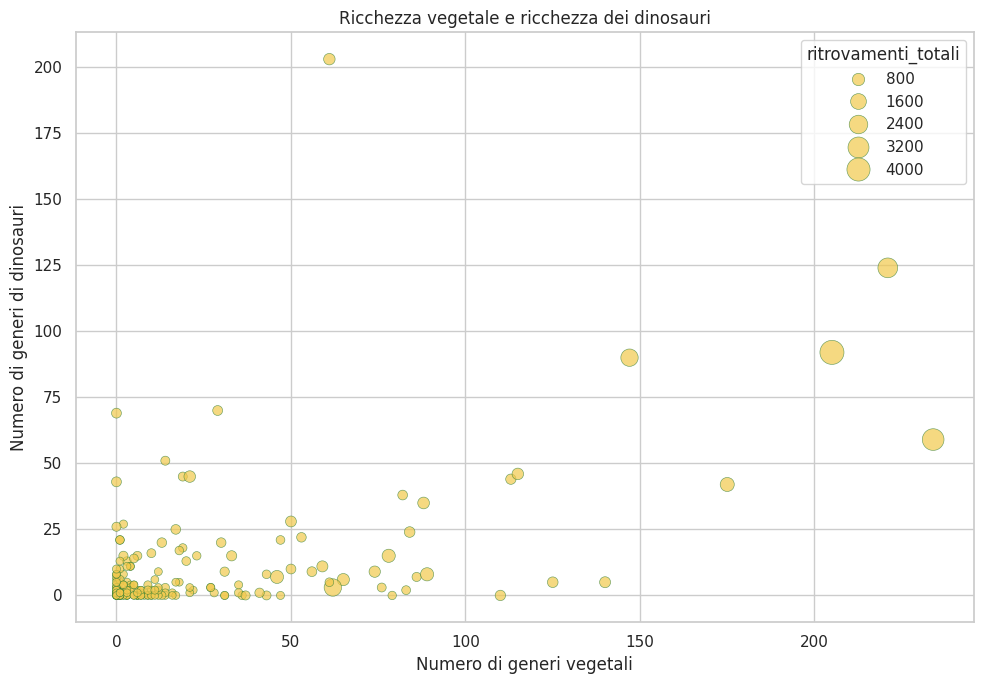

In [62]:
# 34 - Relazione tra ricchezza vegetale e ricchezza dei dinosauri

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=confronto_area,
    x="generi_piante",
    y="generi_dino",
    size="ritrovamenti_totali",
    sizes=(30, 300),
    color=giallo,
    edgecolor=verde,
    alpha=0.7
)

plt.title("Ricchezza vegetale e ricchezza dei dinosauri")
plt.xlabel("Numero di generi vegetali")
plt.ylabel("Numero di generi di dinosauri")
plt.tight_layout()
plt.show()

In [63]:
# 35 - Selezione dei principali paesi comuni

paesi_comuni = (
    pd.concat([
        df_dino_cretaceo["cc"],
        df_plant_cretaceo["cc"]
    ])
    .value_counts()
    .head(12)
    .index
)

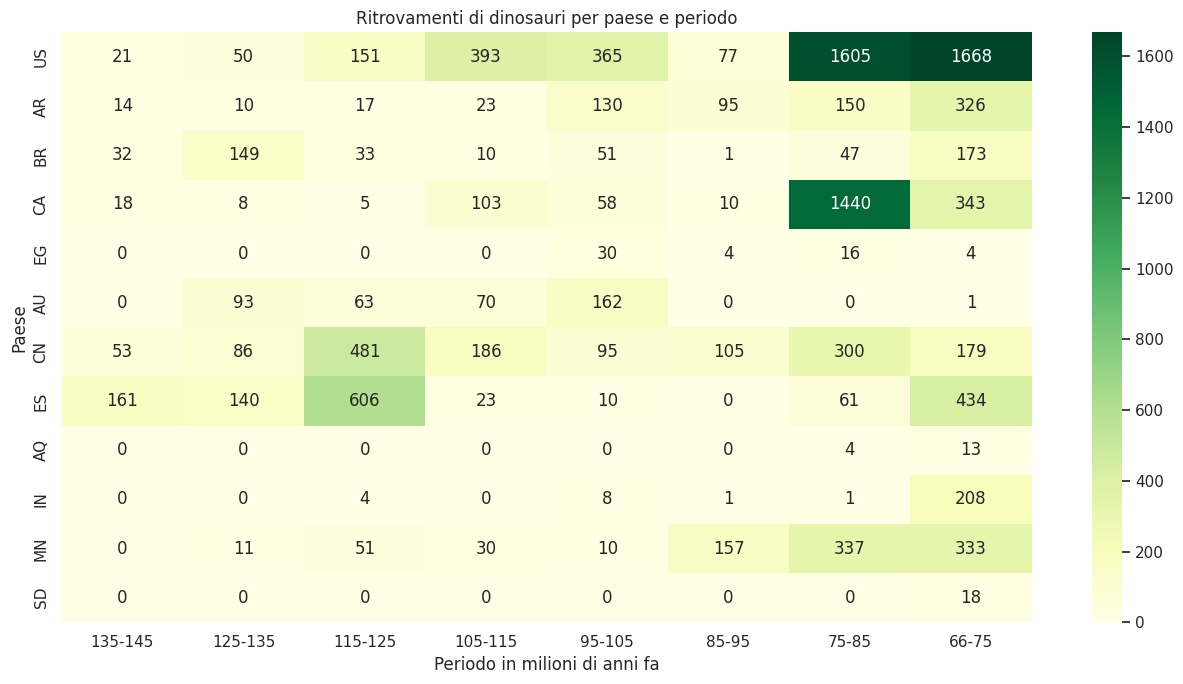

In [64]:
# 36 - Heatmap dei dinosauri per paese e periodo

dati_heatmap_dino = df_dino_cretaceo[
    df_dino_cretaceo["cc"].isin(paesi_comuni)
]

heatmap_dino = (
    pd.crosstab(
        dati_heatmap_dino["cc"],
        dati_heatmap_dino["periodo_10ma"]
    )
    .reindex(
        index=paesi_comuni,
        columns=ordine_periodi,
        fill_value=0
    )
)

plt.figure(figsize=(13, 7))

sns.heatmap(
    heatmap_dino,
    cmap="YlGn",
    annot=True,
    fmt=".0f"
)

plt.title("Ritrovamenti di dinosauri per paese e periodo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Paese")
plt.tight_layout()
plt.show()

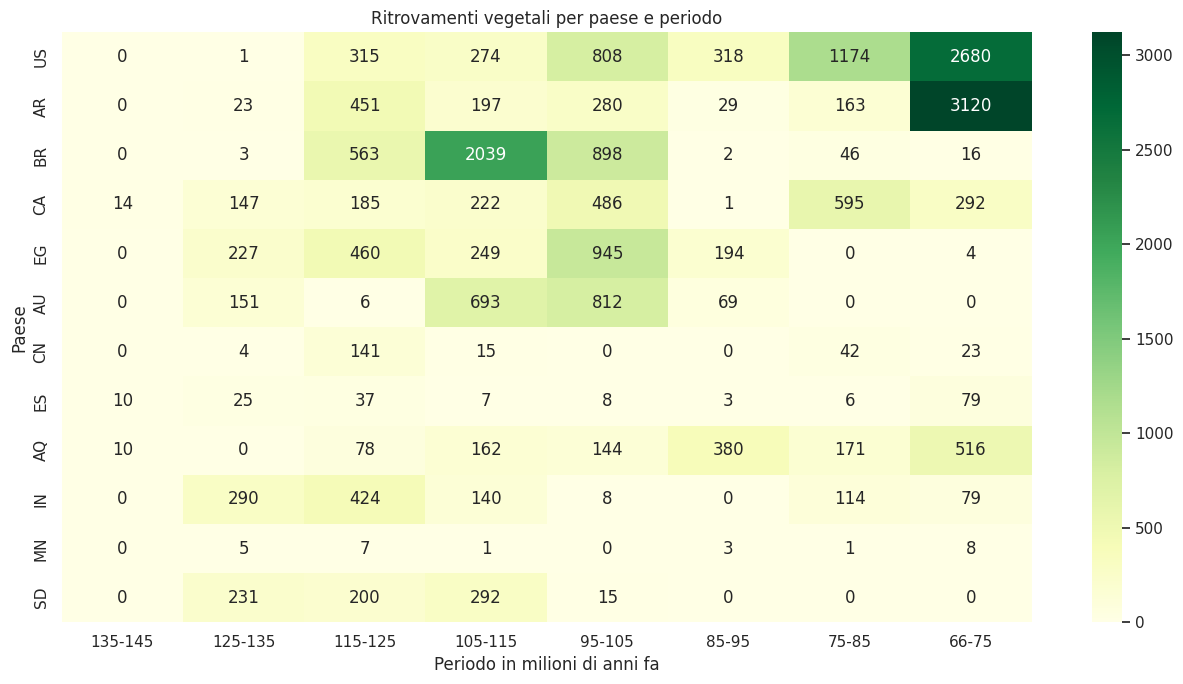

In [65]:
# 37 - Heatmap delle piante per paese e periodo

dati_heatmap_plant = df_plant_cretaceo[
    df_plant_cretaceo["cc"].isin(paesi_comuni)
]

heatmap_plant = (
    pd.crosstab(
        dati_heatmap_plant["cc"],
        dati_heatmap_plant["periodo_10ma"]
    )
    .reindex(
        index=paesi_comuni,
        columns=ordine_periodi,
        fill_value=0
    )
)

plt.figure(figsize=(13, 7))

sns.heatmap(
    heatmap_plant,
    cmap="YlGn",
    annot=True,
    fmt=".0f"
)

plt.title("Ritrovamenti vegetali per paese e periodo")
plt.xlabel("Periodo in milioni di anni fa")
plt.ylabel("Paese")
plt.tight_layout()
plt.show()